# peclet quick start — Stokes flow past a sphere

A self-contained first run of **peclet-flow**: creeping flow through a periodic array of spheres, driven by
a pressure gradient, on the multicore-CPU wheel from PyPI. The whole notebook takes about half a minute on
two cores.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/peclet/blob/main/docs/notebooks/quickstart_sphere.ipynb)

The first cell installs the family (`peclet-flow`, `-pnm`, `-dem`, `-voro`, `-morton`). Use the CPU wheels
here even on a GPU runtime: the CUDA wheels (`peclet-cu13`) need a CUDA 13 capable NVIDIA driver, and
Colab's GPU runtimes currently ship an older one.

In [1]:
%pip install -q peclet

# Kokkos sizes its OpenMP pool from the CPUs it can SEE. A container — Colab, Binder, Docker, a
# Slurm cgroup — normally shows you the whole host while granting a fraction of it through a cgroup
# CPU *quota*, which OpenMP cannot see, so the default pool spin-waits itself to a standstill:
# measured, the 26-second solve below did not finish in 15 minutes on 2 CPUs of quota with 48
# visible. peclet >= 1.0.1 does this for you at import; on 1.0.0 the pool has to be bounded here,
# BEFORE peclet is imported (Kokkos reads the setting once).
import os


def usable_cpus():
    """CPUs this process may actually use: the affinity mask, lowered by any cgroup quota.

    The quota is NOT read from /sys/fs/cgroup/cpu.max — that is the cgroup root, which on a plain
    host says "max" while the real limit sits further down. Resolve this process's own cgroup and
    walk UP: a limit on an ancestor binds just as hard as one on the leaf.
    """
    best = 0
    try:
        lines = open("/proc/self/cgroup").read().splitlines()
    except OSError:
        lines = []
    for line in lines:
        parts = line.split(":", 2)                      # "hierarchy:controllers:path"
        if len(parts) != 3:
            continue
        ctrl, path = parts[1], parts[2]
        if ctrl == "":                                  # cgroup v2, "0::/a/b"
            base, files = "/sys/fs/cgroup" + path, ("cpu.max",)
        elif "cpu" in ctrl.split(","):                  # cgroup v1, "N:cpu,cpuacct:/a/b"
            base, files = "/sys/fs/cgroup/cpu" + path, ("cpu.cfs_quota_us", "cpu.cfs_period_us")
        else:
            continue
        while True:
            try:
                if len(files) == 1:                     # "max 100000" | "200000 100000"
                    q, p = open(base + "/" + files[0]).read().split()
                    n = 0 if q == "max" else -(-int(q) // int(p))
                else:
                    q = int(open(base + "/" + files[0]).read())
                    p = int(open(base + "/" + files[1]).read())
                    n = -(-q // p) if q > 0 else 0
                if n > 0 and (best == 0 or n < best):
                    best = n
            except (OSError, ValueError):
                pass
            if base.count("/") <= 3:                    # reached /sys/fs/cgroup[/cpu]
                break
            base = base.rsplit("/", 1)[0]
    affinity = len(os.sched_getaffinity(0))
    return max(1, min(affinity, best) if best else affinity)


os.environ.setdefault("OMP_NUM_THREADS", str(usable_cpus()))
os.environ.setdefault("OMP_PROC_BIND", "false")
print("OMP_NUM_THREADS =", os.environ["OMP_NUM_THREADS"])


Note: you may need to restart the kernel to use updated packages.
OMP_NUM_THREADS = 2


## The problem and the grid

State the problem in any consistent unit system: a periodic box of side `L` with a sphere of radius `R` at its
centre (so a cubic lattice of spheres), fluid density `rho` and viscosity `mu`, and a driving pressure
gradient `F` along `x`. `N` is the number of cells per side — the one number to change for a refinement study.

The solver is given the **physical domain** (`extent=(L, L, L)`) and derives its own cell size, so nothing
below divides by a spacing. `cell_centers()` returns the coordinates of the grid it laid inside that box —
the points a solid's **signed distance field** is sampled at (negative inside the solid, positive in the
fluid).

In [2]:
import numpy as np
import peclet.flow as flow

L, R = 1.0, 0.2              # box side and sphere radius
rho, mu = 1.0, 0.1           # fluid density and viscosity
F = 1.0                      # driving pressure gradient along x (force per unit volume)
N = 48                       # cells per side

s = flow.Solver((N, N, N), extent=(L, L, L))
x, y, z = s.cell_centers()                                     # physical cell-centre coordinates
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
sdf = np.sqrt((X - L/2)**2 + (Y - L/2)**2 + (Z - L/2)**2) - R  # signed distance, < 0 in the solid
print("cell size:", s.spacing, " solid fraction:", (sdf < 0).mean().round(3))

cell size: [0.020833333333333332, 0.020833333333333332, 0.020833333333333332]  solid fraction: 0.033


## Solve

Creeping (Stokes) flow — advection is off by default. Density, viscosity, the body force, the time step and
the signed distance field are all in the units the problem was stated in, and the velocity and pressure come
back in them too. A large time step lets the implicit solver march straight to the steady state; the loop
stops once the mean velocity has settled. `set_solid` builds the no-slip cut-cell immersed boundary and the
matching pressure operator.

In [3]:
s.set_rho(rho); s.set_mu(mu); s.set_dt(1e3)
s.set_body_force((F, 0.0, 0.0))
s.set_solid(sdf, cutcell_pressure=True)
u_prev = 0.0
for it in range(200):
    s.step()
    u_mean = s.get_u().mean()
    if it > 5 and abs(u_mean - u_prev) < 1e-5 * abs(u_mean):
        break
    u_prev = u_mean
u, v, w = s.get_u(), s.get_v(), s.get_w()                      # physical velocity, arrays indexed [x, y, z]
p = s.get_p()                                                  # physical pressure
k = mu * u.mean() / F                                          # Darcy permeability of the sphere lattice
print(f"{flow.execution_space}: N = {N}, {it + 1} steps, permeability k = {k:.5e}")

OpenMP: N = 48, 42 steps, permeability k = 1.23512e-01


## A look at the flow

Speed and streamlines on the mid-plane through the sphere centre. The white disk is the sphere; the flow
speeds up in the gaps between neighbouring spheres of the periodic lattice.

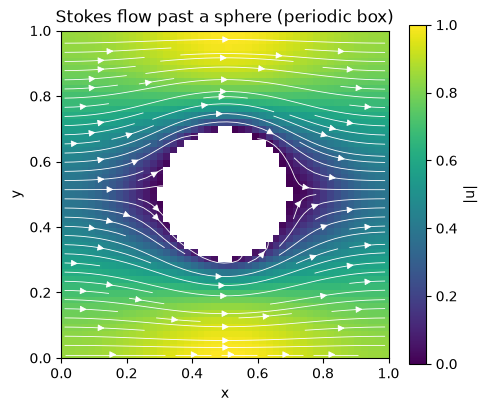

In [4]:
import matplotlib.pyplot as plt

c = N // 2
speed = np.hypot(u[:, :, c], v[:, :, c])
plt.figure(figsize=(5, 4.2))
plt.imshow(np.ma.masked_where(sdf[:, :, c] < 0, speed).T, origin="lower", cmap="viridis", extent=[0, L, 0, L])
plt.streamplot(x, y, u[:, :, c].T, v[:, :, c].T, color="w", density=1.2, linewidth=0.6)
plt.colorbar(label="|u|"); plt.title("Stokes flow past a sphere (periodic box)")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout()

## Where next

- **Grid refinement:** rerun with `N = 24, 32, 64, 96` and watch `k` converge (measured: 0.1245, 0.1235,
  0.1234, 0.1230 for N = 24, 48, 64, 96). Compare against the Zick & Homsy sphere-array reference in the
  [examples gallery](https://computational-chemical-engineering.github.io/peclet-examples/).
- Turn on `s.set_advection(True)` and lower `set_dt` for a Navier–Stokes run; `s.set_domain_bc(face, type)`
  replaces the periodic faces by walls, inflow, outflow or symmetry planes.
- An **analytic** sphere instead of a sampled field: build a scene (`peclet.core.geom.SceneBuilder`, or the
  two flat records `flow.set_scene` takes) and call `set_solid_from_scene`; that also unlocks exact wall
  crossings and moving instances.
- The [Python API reference](https://computational-chemical-engineering.github.io/peclet/python/) lists every
  call; the [examples gallery](https://computational-chemical-engineering.github.io/peclet-examples/) holds
  validated, runnable notebooks for each code.